In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
pd.set_option('display.max_columns', None)

In [4]:
DATA_DIR = Path.cwd().parent / "data" / "raw"

In [5]:
train_values = pd.read_csv(DATA_DIR / "train_values.csv", index_col="sequence_id")
train_labels = pd.read_csv(DATA_DIR / "train_labels.csv", index_col="sequence_id")

In [8]:
train_values.columns

Index(['sequence', 'bacterial_resistance_ampicillin',
       'bacterial_resistance_chloramphenicol',
       'bacterial_resistance_kanamycin', 'bacterial_resistance_other',
       'bacterial_resistance_spectinomycin', 'copy_number_high_copy',
       'copy_number_low_copy', 'copy_number_unknown',
       'growth_strain_ccdb_survival', 'growth_strain_dh10b',
       'growth_strain_dh5alpha', 'growth_strain_neb_stable',
       'growth_strain_other', 'growth_strain_stbl3', 'growth_strain_top10',
       'growth_strain_xl1_blue', 'growth_temp_30', 'growth_temp_37',
       'growth_temp_other', 'selectable_markers_blasticidin',
       'selectable_markers_his3', 'selectable_markers_hygromycin',
       'selectable_markers_leu2', 'selectable_markers_neomycin',
       'selectable_markers_other', 'selectable_markers_puromycin',
       'selectable_markers_trp1', 'selectable_markers_ura3',
       'selectable_markers_zeocin', 'species_budding_yeast', 'species_fly',
       'species_human', 'species_mouse'

In [9]:
train_values.sequence.str.len().describe()

count    63017.000000
mean      4839.025501
std       3883.148431
min         20.000000
25%        909.000000
50%       4741.000000
75%       7490.000000
max      60099.000000
Name: sequence, dtype: float64

In [11]:
train_values.sequence.str.len().quantile([0.90, 0.95, 0.99, 0.999])

0.900     9437.400
0.950    11101.000
0.990    15807.840
0.999    22645.984
Name: sequence, dtype: float64

In [12]:
print((train_values.sequence.str.len()< 100).sum())
print((train_values.sequence.str.len()< 500).sum())
print((train_values.sequence.str.len() < 1000).sum())

26
589
19543


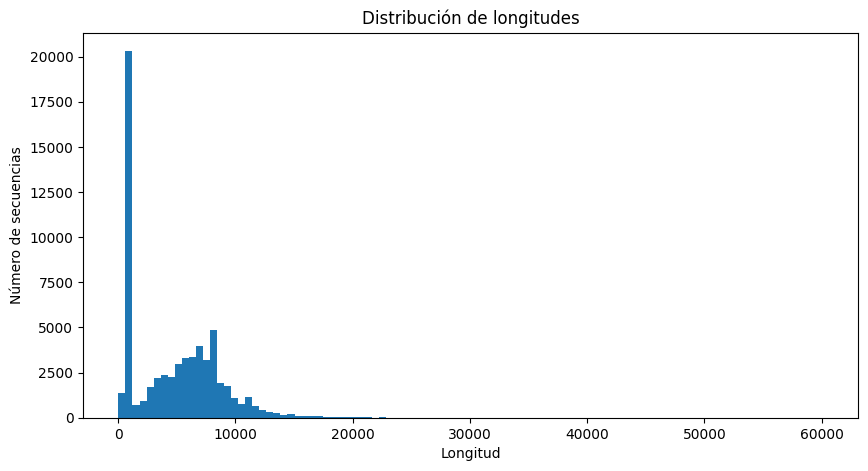

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(train_values.sequence.str.len(), bins=100)
plt.xlabel("Longitud")
plt.ylabel("Número de secuencias")
plt.title("Distribución de longitudes")
plt.show()

In [40]:
len(train_values)

63017

In [46]:
train_values.shape

(63017, 40)

In [41]:
len(train_labels)

63017

In [42]:
lab_ids = pd.DataFrame(train_labels.idxmax(axis=1), columns=["lab_id"])

In [43]:
len(lab_ids)

63017

In [44]:
train_df = train_values.join(lab_ids)

In [45]:
train_df.shape

(63017, 41)

In [99]:
from sklearn.model_selection import train_test_split

train_df, validation_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42
)

In [100]:
import pandas as pd

def create_window_dataset(df, window_size=1000, stride=500, pad_char="N"):
    rows = []

    for idx, row in df.iterrows():
        sequence = row["sequence"]

        # Recorremos la secuencia con una ventana deslizante
        for start in range(0, len(sequence), stride):
            window = sequence[start:start + window_size]

            # Si la ventana quedó incompleta, hacemos padding
            if len(window) < window_size:
                window = window + pad_char * (window_size - len(window))

            # Copiamos toda la fila
            new_row = row.copy()

            # Reemplazamos únicamente la secuencia
            new_row["sequence"] = window

            # Guardamos información útil
            new_row["window_start"] = start
            new_row["window_end"] = min(start + window_size, len(sequence))

            rows.append(new_row)

            # Si ya llegamos al final, terminamos
            if start + window_size >= len(sequence):
                break

    return pd.DataFrame(rows)

In [101]:
train_windows = create_window_dataset(
    train_df,
    window_size=1000,
    stride=500
)

In [102]:
train_windows.head(15)

,sequence,bacterial_resistance_ampicillin,bacterial_resistance_chloramphenicol,bacterial_resistance_kanamycin,bacterial_resistance_other,bacterial_resistance_spectinomycin,copy_number_high_copy,copy_number_low_copy,copy_number_unknown,growth_strain_ccdb_survival,growth_strain_dh10b,growth_strain_dh5alpha,growth_strain_neb_stable,growth_strain_other,growth_strain_stbl3,growth_strain_top10,growth_strain_xl1_blue,growth_temp_30,growth_temp_37,growth_temp_other,selectable_markers_blasticidin,selectable_markers_his3,selectable_markers_hygromycin,selectable_markers_leu2,selectable_markers_neomycin,selectable_markers_other,selectable_markers_puromycin,selectable_markers_trp1,selectable_markers_ura3,selectable_markers_zeocin,species_budding_yeast,species_fly,species_human,species_mouse,species_mustard_weed,species_nematode,species_other,species_rat,species_synthetic,species_zebrafish,lab_id,window_start,window_end
JJHI5,ATCTTCTTGAGATCCTTTTTTTCTGCGCGTAATCTGCTGCTTGCAA...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,637,0,1000
JJHI5,ACGCCTGGTATCTTTATAGTCCTGTCGGGTTTCGCCACCTCTGACT...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,637,500,1500
JJHI5,CACGTTTCTGCGAAAACGCGGGAAAAAGTGGAAGCGGCGATGGCGG...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,637,1000,2000
JJHI5,TCTGCGTCTGGCTGGCTGGCATAAATATCTCACTCGCAATCAAATT...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,637,1500,2500
JJHI5,CGCAACGCAATTAATGTAAGTTAGCTCACTCATTAGGCACCCCAGG...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,637,2000,3000
JJHI5,CATTTAATGTTGATGAAAGCTGGCTACAGGAAGGCCAGACGCGAAT...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,637,2500,3500
JJHI5,TTGATGGTGATGTTAAATTAACACAGTCTATGGCCATCATACGTTA...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,637,3000,4000
JJHI5,TCAGAATTCAAGGTGCACCCCAGCAGCACCCGGGATCCTTAACAAT...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,637,3500,4500
JJHI5,TATTCAACATTTCCGTGTCGCCCTTATTCCCTTTTTTGCGGCATTT...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,637,4000,5000
JJHI5,AAGCCATACCAAACGACGAGCGTGACACCACGATGCCTGCAGCAAT...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,637,4500,5020


In [103]:
train_windows.shape

(460923, 43)

In [104]:
DNA_MAP = {
    "A": [1, 0, 0, 0],
    "C": [0, 1, 0, 0],
    "G": [0, 0, 1, 0],
    "T": [0, 0, 0, 1],
    "N": [0, 0, 0, 0]
}

def one_hot_encode(sequence):
    sequence = sequence.upper()

    return np.array(
        [DNA_MAP.get(base, [0, 0, 0, 0]) for base in sequence],
        dtype=np.float32
    )

In [105]:
bases = set("".join(train_df["sequence"]))
print(sorted(bases))

['A', 'C', 'G', 'N', 'T']


In [106]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df["lab_id"] = label_encoder.fit_transform(train_df["lab_id"])


In [107]:
label_encoder.inverse_transform([8])


array([8])

In [108]:
train_windows.columns

Index(['sequence', 'bacterial_resistance_ampicillin',
       'bacterial_resistance_chloramphenicol',
       'bacterial_resistance_kanamycin', 'bacterial_resistance_other',
       'bacterial_resistance_spectinomycin', 'copy_number_high_copy',
       'copy_number_low_copy', 'copy_number_unknown',
       'growth_strain_ccdb_survival', 'growth_strain_dh10b',
       'growth_strain_dh5alpha', 'growth_strain_neb_stable',
       'growth_strain_other', 'growth_strain_stbl3', 'growth_strain_top10',
       'growth_strain_xl1_blue', 'growth_temp_30', 'growth_temp_37',
       'growth_temp_other', 'selectable_markers_blasticidin',
       'selectable_markers_his3', 'selectable_markers_hygromycin',
       'selectable_markers_leu2', 'selectable_markers_neomycin',
       'selectable_markers_other', 'selectable_markers_puromycin',
       'selectable_markers_trp1', 'selectable_markers_ura3',
       'selectable_markers_zeocin', 'species_budding_yeast', 'species_fly',
       'species_human', 'species_mouse'

In [109]:
# Separar datos
X_sequence = train_windows["sequence"].values

X_metadata = (
    train_windows
    .drop(columns=["sequence", "lab_id",'window_start', 'window_end'])
    .astype(np.float32)
    .values
)

# Convertir etiquetas a enteros
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train_windows["lab_id"])

In [110]:
import tensorflow as tf
import numpy as np

In [111]:
# Crear Dataset
dataset = tf.data.Dataset.from_tensor_slices(
    (X_sequence, X_metadata, y)
)

In [112]:
# Tabla de conversión de nucleótidos
keys = tf.constant(["A", "C", "G", "T", "N"])
values = tf.constant([0, 1, 2, 3, 4])

lookup_table = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(keys, values),
    default_value=4
)

In [113]:
# Función de codificación
def encode(sequence, metadata, label):

    bases = tf.strings.bytes_split(sequence)

    indices = lookup_table.lookup(bases)

    sequence = tf.one_hot(
        indices,
        depth=5,
        dtype=tf.float32
    )

    return (sequence, metadata), label

In [114]:
# Aplicar la codificación
dataset = dataset.map(
    encode,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [115]:
# Agrupar en lotes
dataset = dataset.batch(32)

In [116]:
# Preparar el siguiente lote mientras se entrena el actual
dataset = dataset.prefetch(tf.data.AUTOTUNE)

In [117]:
print(X_metadata.shape)
print(len(label_encoder.classes_))

(460923, 39)
1313


In [121]:
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    Concatenate
)

# Entrada de secuencias
sequence_input = Input(shape=(1000, 5), name="sequence")

x = Conv1D(64, 15, activation="relu", padding="same")(sequence_input)
x = MaxPooling1D(pool_size=2)(x)
x = Conv1D(128, 7, activation="relu", padding="same")(x)
x = GlobalMaxPooling1D()(x)

# Entrada de metadatos
metadata_input = Input(shape=(39,), name="metadata")

m = Dense(64, activation="relu")(metadata_input)

# Unir ambas ramas
combined = Concatenate()([x, m])

combined = Dense(128, activation="relu")(combined)
combined = Dropout(0.3)(combined)

# Salida
output = Dense(1314, activation="softmax")(combined)

# Modelo
model = Model(
    inputs=[sequence_input, metadata_input],
    outputs=output
)


model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=10, name="top10_accuracy")
    ]
)


In [122]:
# Resumen
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence            │ (None, 1000, 5)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 1000, 64)  │      4,864 │ sequence[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_3     │ (None, 500, 64)   │          0 │ conv1d_6[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 500, 128)  │     57,472 │ max_pooling1d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_7[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │      2,560 │ metadata[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 192)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 128)       │     24,704 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1314)      │    169,506 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 259,106 (1012.13 KB)

 Trainable params: 259,106 (1012.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento
history = model.fit(
    dataset,
    epochs=10
)

Epoch 1/10
 2014/14404 ━━━━━━━━━━━━━━━━━━━━ 7:31 36ms/step - accuracy: 0.1913 - loss: 5.7032 - top10_accuracy: 0.3452